#Collecting Data

In [6]:
import zipfile

zip_files = [
    "BraTS20_Training_001_flair.nii.zip",
    "BraTS20_Training_001_seg.nii.zip"
]

for z in zip_files:
    with zipfile.ZipFile(z, 'r') as zip_ref:
        zip_ref.extractall("data")

print("Done")

Done


In [7]:
import nibabel as nib

img = nib.load("data/BraTS20_Training_001_flair.nii")
data = img.get_fdata()

print(data.shape)

(240, 240, 155)


#Data Preprocessing

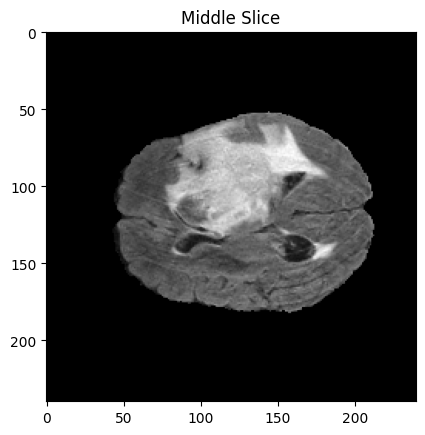

In [8]:
import matplotlib.pyplot as plt

plt.imshow(data[:, :, data.shape[2]//2], cmap='gray')
plt.title("Middle Slice")
plt.show()

In [9]:
import nibabel as nib

# already did this
img = nib.load("data/BraTS20_Training_001_flair.nii")
data = img.get_fdata()

# THIS is what you're missing
seg = nib.load("data/BraTS20_Training_001_seg.nii")
seg_data = seg.get_fdata()

In [10]:
print(seg_data.shape)
print(data.shape)


(240, 240, 155)
(240, 240, 155)


In [11]:
import numpy as np

images = []
labels = []

for i in range(data.shape[2]):
    img_slice = data[:, :, i]
    mask_slice = seg_data[:, :, i]

    if np.sum(mask_slice) > 0:
        images.append(img_slice)
        labels.append(1)

In [12]:
print(len(images))

83


In [13]:
non_tumor_images = []

for i in range(data.shape[2]):
    img_slice = data[:, :, i]
    mask_slice = seg_data[:, :, i]

    if np.sum(mask_slice) == 0:  # no tumor
        non_tumor_images.append(img_slice)

In [14]:
non_tumor_images = non_tumor_images[:83]

In [15]:
X = images + non_tumor_images
y = [1]*len(images) + [0]*len(non_tumor_images)

In [26]:
def normalize(img):
    min_val = np.min(img)
    max_val = np.max(img)

    if max_val - min_val == 0:
        return np.zeros_like(img)   # safe fallback
    else:
        return (img - min_val) / (max_val - min_val)
import cv2

processed_X = []

for img in X:
    img = normalize(img)
    img = cv2.resize(img, (224, 224))

    processed_X.append(img)

In [27]:
print(len(processed_X))

155


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    processed_X, y, test_size=0.2, random_state=42
)

In [29]:
import numpy as np

X_train = np.array(X_train,dtype=np.float32)
X_val = np.array(X_val,dtype=np.float32)

X_train = np.stack([X_train]*3, axis=1)
X_val = np.stack([X_val]*3, axis=1)

y_train = np.array(y_train)
y_val = np.array(y_val)

print(X_train.shape)  # should be (N, 3, 224, 224)

(124, 3, 224, 224)


#Modeling

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 2)
)

model = model.to(device)

In [41]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.0003)

In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
X_val = torch.tensor(X_val, dtype=torch.float32).to(device)

y_train = torch.tensor(y_train, dtype=torch.long).to(device)
y_val = torch.tensor(y_val, dtype=torch.long).to(device)

#Train And eval

In [43]:
for epoch in range(5):
    model.train()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

        train_acc = (outputs.argmax(1) == y_train).float().mean()
        val_acc = (val_outputs.argmax(1) == y_val).float().mean()

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {loss.item():.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss.item():.4f}, Val Acc: {val_acc:.4f}")

Epoch 1
Train Loss: 0.7177, Train Acc: 0.5242
Val Loss: 0.6543, Val Acc: 0.5484
Epoch 2
Train Loss: 0.6414, Train Acc: 0.6613
Val Loss: 0.6459, Val Acc: 0.5484
Epoch 3
Train Loss: 0.5749, Train Acc: 0.8145
Val Loss: 0.6377, Val Acc: 0.5806
Epoch 4
Train Loss: 0.5459, Train Acc: 0.8468
Val Loss: 0.6278, Val Acc: 0.6129
Epoch 5
Train Loss: 0.5067, Train Acc: 0.8952
Val Loss: 0.6132, Val Acc: 0.7097


#QC Score Analysis

In [46]:
def qc_score(img):
    brightness = np.mean(img)
    noise = np.std(img)

    score = 1.0

    if brightness < 0.3:
        score -= 0.4
    if noise > 0.5:
        score -= 0.4

    return max(score, 0)

In [47]:
model.eval()

with torch.no_grad():
    outputs = model(X_val)
    preds = outputs.argmax(1).cpu().numpy()

X_val_np = X_val.cpu().numpy()
y_val_np = y_val.cpu().numpy()

In [48]:
X_val_gray = X_val_np[:, 0, :, :]
qc_scores = [qc_score(img) for img in X_val_gray]

In [49]:
good_idx = np.argmax(qc_scores)
bad_idx = np.argmin(qc_scores)

#Visualizing


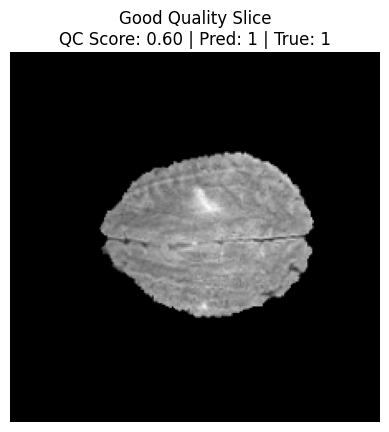

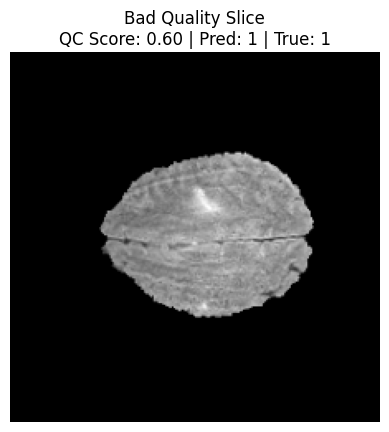

In [50]:
import matplotlib.pyplot as plt

def show_sample(idx, title):
    plt.imshow(X_val_gray[idx], cmap='gray')
    plt.title(
        f"{title}\n"
        f"QC Score: {qc_scores[idx]:.2f} | "
        f"Pred: {preds[idx]} | True: {y_val_np[idx]}"
    )
    plt.axis('off')
    plt.show()

# Show best quality slice
show_sample(good_idx, "Good Quality Slice")

# Show worst quality slice
show_sample(bad_idx, "Bad Quality Slice")